# Chapter 3 (Burden): Interpolation and Polynomial Approximation

This notebook is a self-contained study guide + lab for Chapter 3 style topics.

Main emphasis: **interpolation polynomials** and **divided differences**.

## What We Cover

1. Interpolation problem and uniqueness
2. Lagrange interpolation polynomial
3. Newton form via divided differences (main focus)
4. Neville's algorithm
5. Hermite interpolation
6. Piecewise interpolation and natural cubic splines

References used for verification and framing (web):
- Polynomial interpolation (Wikipedia)
- Divided differences (Wikipedia)
- Neville's algorithm (Wikipedia)
- Hermite interpolation (Wikipedia)
- Spline interpolation (Wikipedia)

The explanations below are original summaries and worked examples, not copied textbook text.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True)
plt.rcParams['figure.figsize'] = (8, 4.5)
plt.rcParams['axes.grid'] = True

## 3.1 Interpolation Polynomial Basics

Given distinct nodes $x_0,\dots,x_n$ and values $y_i=f(x_i)$, there is a **unique** polynomial $p_n$ of degree at most $n$ with
$$p_n(x_i)=y_i,\; i=0,\dots,n.$$

This is the core theorem behind Lagrange and Newton interpolation forms.

max error on [0,1.5]: 6.321e-03


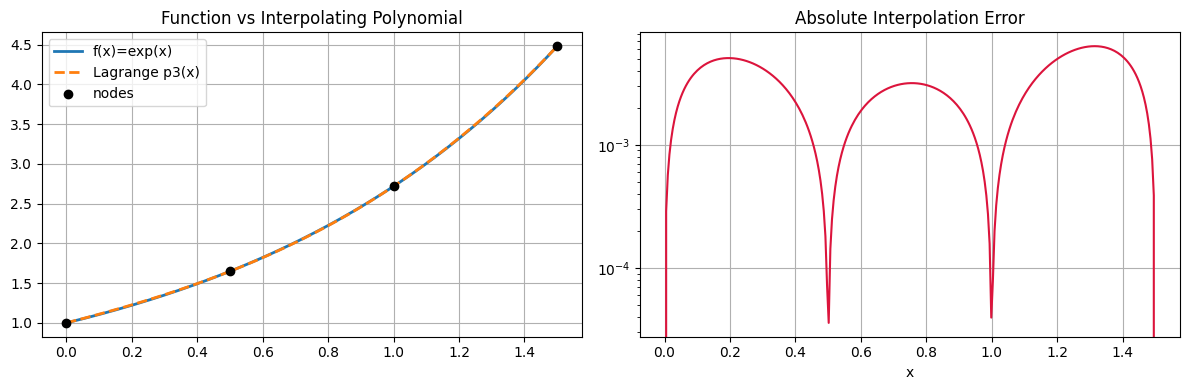

In [3]:
def lagrange_basis(x_nodes, j, x):
    x_nodes = np.asarray(x_nodes, dtype=float)
    x = np.asarray(x, dtype=float)
    L = np.ones_like(x, dtype=float)
    xj = x_nodes[j]
    for m, xm in enumerate(x_nodes):
        if m != j:
            L *= (x - xm) / (xj - xm)
    return L

def lagrange_interpolate(x_nodes, y_nodes, x):
    x_nodes = np.asarray(x_nodes, dtype=float)
    y_nodes = np.asarray(y_nodes, dtype=float)
    x = np.asarray(x, dtype=float)
    p = np.zeros_like(x, dtype=float)
    for j in range(len(x_nodes)):
        p += y_nodes[j] * lagrange_basis(x_nodes, j, x)
    return p

f = np.exp
x_nodes = np.array([0.0, 0.5, 1.0, 1.5])
y_nodes = f(x_nodes)
x_plot = np.linspace(0, 1.5, 300)

p_plot = lagrange_interpolate(x_nodes, y_nodes, x_plot)
err = np.abs(f(x_plot) - p_plot)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(x_plot, f(x_plot), label='f(x)=exp(x)', linewidth=2)
ax[0].plot(x_plot, p_plot, '--', label='Lagrange p3(x)', linewidth=2)
ax[0].scatter(x_nodes, y_nodes, color='black', zorder=3, label='nodes')
ax[0].set_title('Function vs Interpolating Polynomial')
ax[0].legend()

ax[1].plot(x_plot, err, color='crimson')
ax[1].set_title('Absolute Interpolation Error')
ax[1].set_yscale('log')
ax[1].set_xlabel('x')

plt.tight_layout()
print(f'max error on [0,1.5]: {err.max():.3e}')

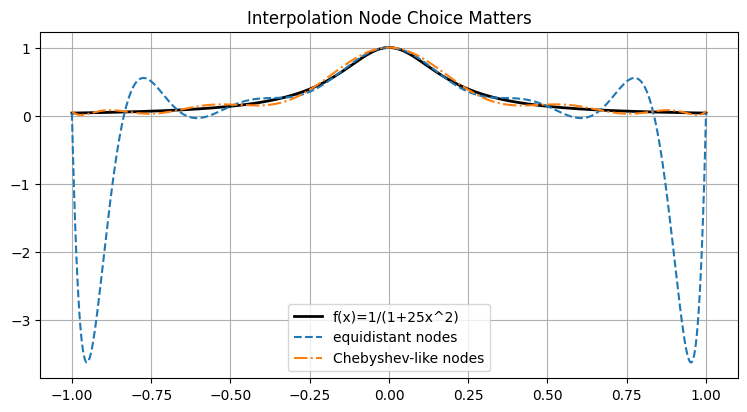

max error equidistant: 3.663e+00
max error Chebyshev-like: 6.921e-02


In [4]:
# Runge-style behavior: equidistant nodes vs Chebyshev-like nodes
def runge(x):
    return 1.0 / (1.0 + 25.0 * x**2)

def chebyshev_nodes(a, b, n):
    k = np.arange(n + 1)
    t = np.cos((2 * k + 1) * np.pi / (2 * (n + 1)))
    return 0.5 * (a + b) + 0.5 * (b - a) * t

n = 12
x_eq = np.linspace(-1, 1, n + 1)
x_ch = np.sort(chebyshev_nodes(-1, 1, n))
y_eq = runge(x_eq)
y_ch = runge(x_ch)

x_plot = np.linspace(-1, 1, 600)
p_eq = lagrange_interpolate(x_eq, y_eq, x_plot)
p_ch = lagrange_interpolate(x_ch, y_ch, x_plot)
f_plot = runge(x_plot)

plt.figure(figsize=(9, 4.5))
plt.plot(x_plot, f_plot, 'k', linewidth=2, label='f(x)=1/(1+25x^2)')
plt.plot(x_plot, p_eq, '--', label='equidistant nodes')
plt.plot(x_plot, p_ch, '-.', label='Chebyshev-like nodes')
plt.title('Interpolation Node Choice Matters')
plt.legend()
plt.show()

eq_err = np.max(np.abs(f_plot - p_eq))
ch_err = np.max(np.abs(f_plot - p_ch))
print(f'max error equidistant: {eq_err:.3e}')
print(f'max error Chebyshev-like: {ch_err:.3e}')

## 3.2 Divided Differences (Main Focus)

For distinct nodes, divided differences are defined recursively:
$$f[x_i]=f(x_i),\quad f[x_i,\dots,x_{i+k}] = \frac{f[x_{i+1},\dots,x_{i+k}] - f[x_i,\dots,x_{i+k-1}]}{x_{i+k}-x_i}. $$

Newton form then becomes
$$p_n(x)=f[x_0] + f[x_0,x_1](x-x_0)+\cdots+f[x_0,\dots,x_n]\prod_{j=0}^{n-1}(x-x_j).$$

Advantages:
- Efficient table construction in $O(n^2)$
- Easy to update when a new node is added
- Numerically practical compared with solving a Vandermonde system directly

In [5]:
def divided_difference_table(x_nodes, y_nodes):
    x_nodes = np.asarray(x_nodes, dtype=float)
    n = len(x_nodes)
    table = np.zeros((n, n), dtype=float)
    table[:, 0] = y_nodes

    for j in range(1, n):
        for i in range(n - j):
            table[i, j] = (table[i + 1, j - 1] - table[i, j - 1]) / (x_nodes[i + j] - x_nodes[i])
    return table

def newton_coefficients_from_table(table):
    return table[0, :]

x_nodes = np.array([0.0, 0.4, 1.0, 1.4, 2.0])
f = np.log1p
y_nodes = f(x_nodes)

dd_table = divided_difference_table(x_nodes, y_nodes)
coeffs = newton_coefficients_from_table(dd_table)

print('Divided-difference table (upper-left triangular):')
print(dd_table)
print('\nNewton coefficients a_k = f[x0,...,xk]:')
print(coeffs)

Divided-difference table (upper-left triangular):
[[ 0.        0.841181 -0.246722  0.077191 -0.021484]
 [ 0.336472  0.594458 -0.138654  0.034223  0.      ]
 [ 0.693147  0.455804 -0.083898  0.        0.      ]
 [ 0.875469  0.371906  0.        0.        0.      ]
 [ 1.098612  0.        0.        0.        0.      ]]

Newton coefficients a_k = f[x0,...,xk]:
[ 0.        0.841181 -0.246722  0.077191 -0.021484]


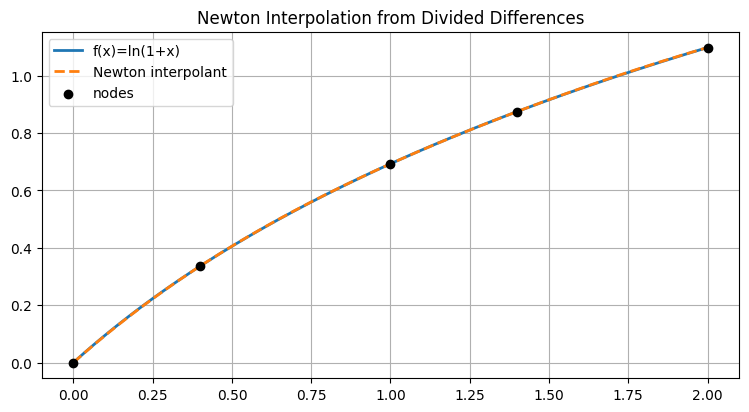

max abs error on [0,2]: 0.001059607850453892


In [6]:
def evaluate_newton_poly(x_nodes, coeffs, x):
    x_nodes = np.asarray(x_nodes, dtype=float)
    coeffs = np.asarray(coeffs, dtype=float)
    x = np.asarray(x, dtype=float)

    # Nested multiplication in Newton basis
    p = np.full_like(x, coeffs[-1], dtype=float)
    for k in range(len(coeffs) - 2, -1, -1):
        p = coeffs[k] + (x - x_nodes[k]) * p
    return p

x_plot = np.linspace(0, 2, 400)
p_newton = evaluate_newton_poly(x_nodes, coeffs, x_plot)
f_plot = np.log1p(x_plot)

plt.figure(figsize=(9, 4.5))
plt.plot(x_plot, f_plot, label='f(x)=ln(1+x)', linewidth=2)
plt.plot(x_plot, p_newton, '--', label='Newton interpolant', linewidth=2)
plt.scatter(x_nodes, y_nodes, color='black', zorder=3, label='nodes')
plt.title('Newton Interpolation from Divided Differences')
plt.legend()
plt.show()

print('max abs error on [0,2]:', np.max(np.abs(f_plot - p_newton)))

Old Newton coefficients:
[ 0.        0.841181 -0.246722  0.077191 -0.021484]

Updated coefficients after adding x=2.4:
[ 0.        0.841181 -0.246722  0.077191 -0.021484  0.005527]


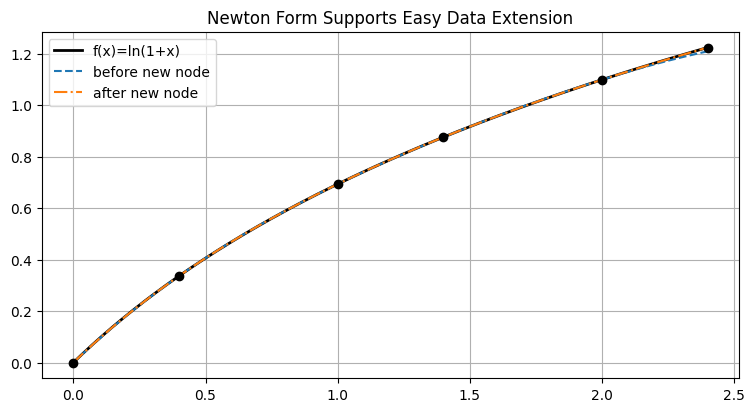

In [7]:
# Incremental update demonstration: add one extra node
x_new = np.append(x_nodes, 2.4)
y_new = np.log1p(x_new)

dd_old = divided_difference_table(x_nodes, y_nodes)
dd_new = divided_difference_table(x_new, y_new)

print('Old Newton coefficients:')
print(dd_old[0, :])
print('\nUpdated coefficients after adding x=2.4:')
print(dd_new[0, :])

x_plot = np.linspace(0, 2.4, 500)
p_old = evaluate_newton_poly(x_nodes, dd_old[0, :], x_plot)
p_new = evaluate_newton_poly(x_new, dd_new[0, :], x_plot)
f_plot = np.log1p(x_plot)

plt.figure(figsize=(9, 4.5))
plt.plot(x_plot, f_plot, 'k', linewidth=2, label='f(x)=ln(1+x)')
plt.plot(x_plot, p_old, '--', label='before new node')
plt.plot(x_plot, p_new, '-.', label='after new node')
plt.scatter(x_new, y_new, color='black', zorder=3)
plt.title('Newton Form Supports Easy Data Extension')
plt.legend()
plt.show()

## 3.3 Neville's Algorithm

Neville's algorithm evaluates the interpolation polynomial at a target point $x$ **without explicitly forming coefficients**.

Recurrence:
$$P_{i,i}(x)=y_i,\quad P_{i,j}(x)=\frac{(x-x_i)P_{i+1,j}(x)-(x-x_j)P_{i,j-1}(x)}{x_j-x_i}. $$

It is a dynamic-programming triangle and is very useful when you only need one interpolated value.

In [8]:
def neville(x_nodes, y_nodes, x_eval):
    x_nodes = np.asarray(x_nodes, dtype=float)
    q = np.array(y_nodes, dtype=float).copy()
    n = len(x_nodes)

    for m in range(1, n):
        for i in range(n - m):
            j = i + m
            q[i] = ((x_eval - x_nodes[i]) * q[i + 1] - (x_eval - x_nodes[j]) * q[i]) / (x_nodes[j] - x_nodes[i])
    return q[0]

x_nodes = np.array([0.0, 0.4, 1.0, 1.4, 2.0])
y_nodes = np.log1p(x_nodes)
x_eval = 1.2

val_neville = neville(x_nodes, y_nodes, x_eval)
dd = divided_difference_table(x_nodes, y_nodes)
val_newton = evaluate_newton_poly(x_nodes, dd[0, :], np.array([x_eval]))[0]
true_val = np.log1p(x_eval)

print(f'Neville value at x={x_eval}:   {val_neville:.12f}')
print(f'Newton value at x={x_eval}:    {val_newton:.12f}')
print(f'True value ln(1+x):            {true_val:.12f}')
print(f'Absolute error (Neville):      {abs(val_neville-true_val):.3e}')

Neville value at x=1.2:   0.788209006056
Newton value at x=1.2:    0.788209006056
True value ln(1+x):            0.788457360364
Absolute error (Neville):      2.484e-04


## 3.4 Hermite Interpolation

Hermite interpolation extends value-matching by also matching derivatives at nodes.

Simple case: for each node $x_i$, we know $f(x_i)$ and $f'(x_i)$. One way is repeated nodes in a divided-difference table: duplicate each node and use
$$f[x_i,x_i]=f'(x_i).$$

This builds a Newton-form Hermite polynomial.

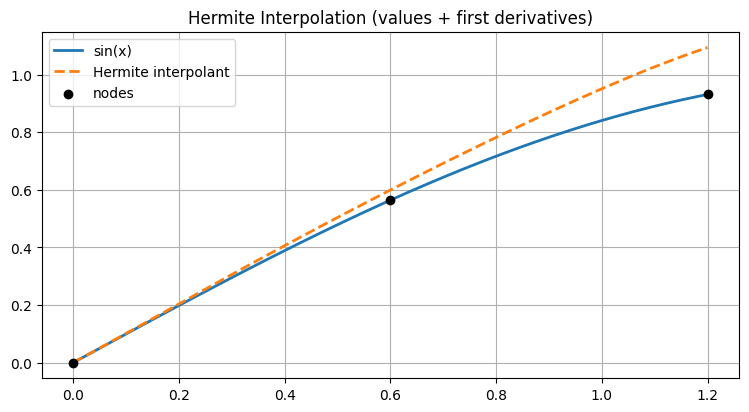

Hermite first-row coefficients (Newton form):
[ 0.        1.        0.       -0.163692  0.070663 -0.191736]


In [9]:
def hermite_divided_differences(x_nodes, y_nodes, yp_nodes):
    x_nodes = np.asarray(x_nodes, dtype=float)
    y_nodes = np.asarray(y_nodes, dtype=float)
    yp_nodes = np.asarray(yp_nodes, dtype=float)
    n = len(x_nodes)

    z = np.repeat(x_nodes, 2)
    Q = np.zeros((2 * n, 2 * n), dtype=float)

    for i in range(n):
        Q[2 * i, 0] = y_nodes[i]
        Q[2 * i + 1, 0] = y_nodes[i]
        Q[2 * i + 1, 1] = yp_nodes[i]
        if i == 0:
            Q[2 * i, 1] = yp_nodes[i]
        else:
            Q[2 * i, 1] = (Q[2 * i, 0] - Q[2 * i - 1, 0]) / (z[2 * i] - z[2 * i - 1])

    m = 2 * n
    for j in range(2, m):
        for i in range(m - j):
            Q[i, j] = (Q[i + 1, j - 1] - Q[i, j - 1]) / (z[i + j] - z[i])

    coeffs = Q[0, :]
    return z, coeffs, Q

x_h = np.array([0.0, 0.6, 1.2])
f = np.sin
fp = np.cos
y_h = f(x_h)
yp_h = fp(x_h)

z_h, c_h, Q_h = hermite_divided_differences(x_h, y_h, yp_h)

x_plot = np.linspace(0, 1.2, 400)
p_h = evaluate_newton_poly(z_h, c_h, x_plot)

plt.figure(figsize=(9, 4.5))
plt.plot(x_plot, np.sin(x_plot), label='sin(x)', linewidth=2)
plt.plot(x_plot, p_h, '--', label='Hermite interpolant', linewidth=2)
plt.scatter(x_h, y_h, color='black', zorder=3, label='nodes')
plt.title('Hermite Interpolation (values + first derivatives)')
plt.legend()
plt.show()

print('Hermite first-row coefficients (Newton form):')
print(c_h)

## 3.5 Piecewise Linear and Cubic Spline Interpolation

High-degree global polynomials can oscillate. Splines avoid this by using low-degree pieces with continuity conditions.

For a natural cubic spline on nodes $x_0<\cdots<x_n$, we enforce:
- Interpolation at each node
- Continuity of first and second derivatives at interior nodes
- Natural boundary conditions: $S''(x_0)=S''(x_n)=0$

This leads to a tridiagonal linear system for second derivatives.

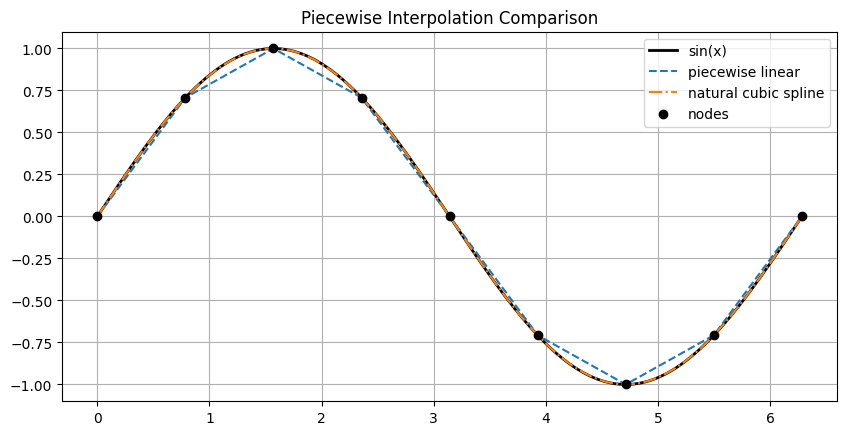

max error piecewise linear: 0.0703768824222809
max error natural spline:  0.001066082992281392


In [10]:
def piecewise_linear_interp(x_nodes, y_nodes, x_eval):
    x_nodes = np.asarray(x_nodes, dtype=float)
    y_nodes = np.asarray(y_nodes, dtype=float)
    x_eval = np.asarray(x_eval, dtype=float)
    return np.interp(x_eval, x_nodes, y_nodes)

def natural_cubic_spline_setup(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    n = len(x) - 1
    h = np.diff(x)

    A = np.zeros((n + 1, n + 1), dtype=float)
    rhs = np.zeros(n + 1, dtype=float)

    A[0, 0] = 1.0
    A[n, n] = 1.0

    for i in range(1, n):
        A[i, i - 1] = h[i - 1]
        A[i, i] = 2 * (h[i - 1] + h[i])
        A[i, i + 1] = h[i]
        rhs[i] = 6 * ((y[i + 1] - y[i]) / h[i] - (y[i] - y[i - 1]) / h[i - 1])

    M = np.linalg.solve(A, rhs)
    return M

def natural_cubic_spline_eval(x, y, M, x_eval):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    M = np.asarray(M, dtype=float)
    x_eval = np.asarray(x_eval, dtype=float)

    vals = np.zeros_like(x_eval, dtype=float)
    n = len(x) - 1

    for k, xv in enumerate(x_eval):
        i = np.searchsorted(x, xv) - 1
        i = max(0, min(i, n - 1))
        h = x[i + 1] - x[i]

        a = (x[i + 1] - xv) / h
        b = (xv - x[i]) / h

        vals[k] = (
            a * y[i]
            + b * y[i + 1]
            + ((a**3 - a) * M[i] + (b**3 - b) * M[i + 1]) * h**2 / 6
        )

    return vals

x_nodes = np.linspace(0, 2 * np.pi, 9)
y_nodes = np.sin(x_nodes)

M = natural_cubic_spline_setup(x_nodes, y_nodes)
x_plot = np.linspace(0, 2 * np.pi, 500)

y_lin = piecewise_linear_interp(x_nodes, y_nodes, x_plot)
y_spl = natural_cubic_spline_eval(x_nodes, y_nodes, M, x_plot)
y_true = np.sin(x_plot)

plt.figure(figsize=(10, 4.8))
plt.plot(x_plot, y_true, 'k', linewidth=2, label='sin(x)')
plt.plot(x_plot, y_lin, '--', label='piecewise linear')
plt.plot(x_plot, y_spl, '-.', label='natural cubic spline')
plt.scatter(x_nodes, y_nodes, color='black', zorder=3, label='nodes')
plt.title('Piecewise Interpolation Comparison')
plt.legend()
plt.show()

print('max error piecewise linear:', np.max(np.abs(y_true - y_lin)))
print('max error natural spline: ', np.max(np.abs(y_true - y_spl)))

## Suggested Exercises

### A. Interpolation Polynomials (core)
1. For $f(x)=\cos(x)$ on $[0,1]$, build degree-2, 3, and 4 Lagrange interpolants on equally spaced nodes. Compare max error.
2. Redo Exercise 1 with Chebyshev-like nodes and explain the error difference.
3. Prove uniqueness of the interpolating polynomial using the zero-count argument for nonzero polynomials.

### B. Divided Differences (main emphasis)
1. Manually compute a full divided-difference table for 5 points from $f(x)=\ln(1+x)$. Check against code.
2. Show numerically that if $p$ is a polynomial of degree $m$, then all divided differences of order $>m$ are zero (up to floating-point noise).
3. Add one new node to an existing Newton polynomial and update only the needed coefficients. Measure added cost.
4. For random node orderings, verify that the final interpolant is unchanged (divided differences are symmetric in nodes as a set, though the table layout changes).

### C. Neville and Hermite
1. Implement Neville with a 2D tableau and with an in-place 1D array. Compare memory usage.
2. Build Hermite interpolation for $f(x)=e^x$ at two nodes with value and first derivative constraints. Verify exact matching of both $f$ and $f'$.

### D. Splines
1. Compare piecewise linear, natural cubic spline, and global degree-8 interpolation on noisy data. Discuss smoothness and stability.
2. Modify the natural spline code to clamped spline by prescribing endpoint slopes.

### Challenge
Create a mini-report: for one smooth function and one non-smooth function, compare all Chapter 3 interpolants in terms of accuracy, stability, and implementation complexity.

## Quick Recap

- Lagrange form is conceptually direct.
- Newton form with divided differences is computationally flexible and update-friendly.
- Neville is ideal for evaluating at one point without constructing full coefficients.
- Hermite adds derivative matching.
- Splines reduce oscillation risk by using low-degree local pieces.

If you want, we can next turn this into a graded worksheet with hidden-solution cells.